# Assignment 3. Frequency Domain Processing

<span style="color:orange">Ground Rules for the Assignment: </span>

* <span style="color:lightblue"> You can only use basic functions (matrix operations, input/output image functions, plotters). Anything else, you need to code from scratch (histogram functions, inverting gamma functions, color matting, histogram equalization)</span>
* <span style="color:lightblue"> The code needs to be appropiately commented and should be reproducible; if we cannot re-generate your figures from your code, we will deduct points.</span>
* <span style="color:lightblue">The notebook report should be detailed and include partial and final solutions for each exercise. We grade solely the report; code without report will not be graded, so we encourage that you invest some time on it</span>
* <span style="color:lightblue">Interactive plots are welcome but most important results should be static and generated beforehand</span>
* <span style="color:lightblue">__Remember to remove all plots from the "coding" sections.__ Only the Report should output plots and/or images.</span>


<span style="color:orange">Submission Details</span>

Simply submit this Jupyter Notebook with the report inlined as described below. The notebook should be executed before submission. Name the file as 
```surname1_name1_surname2_name2_assignment3.ipynb```


In [2]:
# Loading Libraries you will need for the assignment.- Install them in your environment if you haven't done so yet
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2 #opencv python

## 1. Gaussian Filtering [10 points]
In this exercise we will be working on filtering and the connection between spatial and frequency domain filtering.
### _Tasks_

* Implement Gaussian filtering both in the spatial and frequency domains
* Demonstrate that convolving an image with a Gaussian filter with standard deviation $\sigma_s$ in the spatial domain is equivalent to point-wise multiplication in the frequency domain with Gaussian filter with standard deviation $\sigma_f = \frac{1}{2\sigma{s}\pi}$
* Analyze how the performance of equivalent filtering in spatial and temporal domains depends on the parameter $\sigma_s$

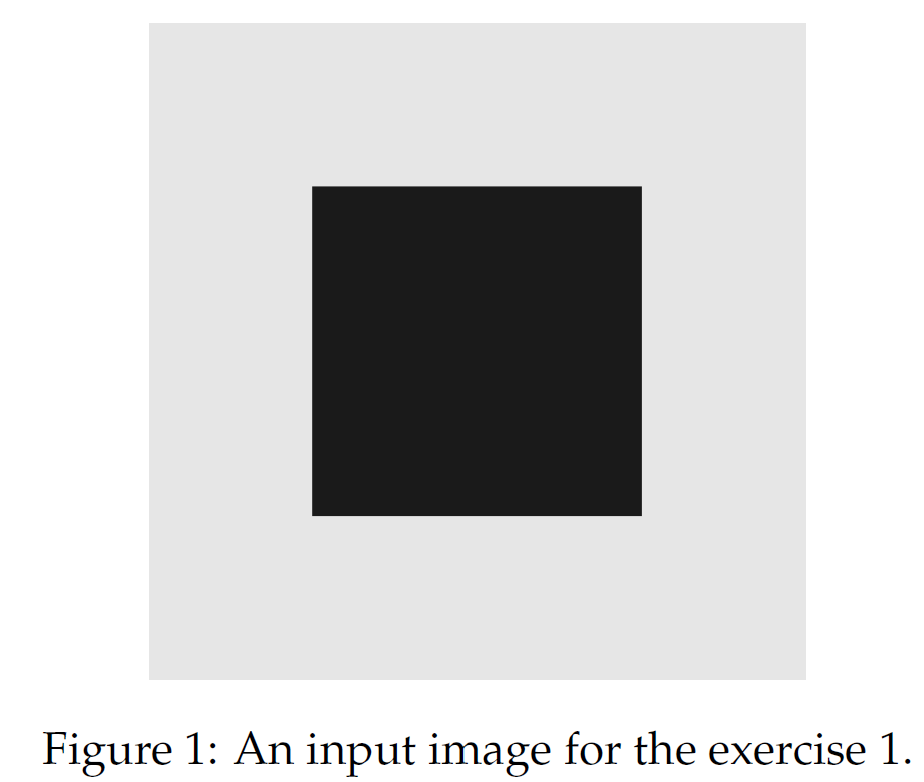

In [59]:

import time


def create_test_image(size=256, square_size=100, bg_value=0.9, fg_value=0.15):
    img = np.full((size, size), bg_value, dtype=np.float64)
    start = (size - square_size) // 2
    end = start + square_size
    img[start:end, start:end] = fg_value
    return img


# Generate a 2D Gaussian convolution kernel with a radius (3σ truncation)
def gaussian_kernel_2d(sigma, truncate=3.0):

    radius = int(np.ceil(truncate * sigma))
    x = np.arange(-radius, radius + 1)
    xx, yy = np.meshgrid(x, x)
    kernel = np.exp(-(xx**2 + yy**2) / (2.0 * sigma**2))
    kernel /= kernel.sum()      
    return kernel


def gaussian_filter_spatial(image, sigma_s):

    kernel = gaussian_kernel_2d(sigma_s)
    kh, kw = kernel.shape
    pad_h, pad_w = kh // 2, kw // 2

# Zero padding for images.
    padded = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)),
                    mode='constant', constant_values=0)

    H, W = image.shape
    out = np.zeros_like(image)

    for i in range(kh):
        for j in range(kw):
            out += kernel[i, j] * padded[i:i + H, j:j + W]
    return out


# Frequency domain Gaussian filtering.
def gaussian_filter_frequency(image, sigma_f):

    H, W = image.shape

    P, Q = 2 * H, 2 * W
    padded = np.zeros((P, Q), dtype=np.float64)
    padded[:H, :W] = image

    u = np.fft.fftfreq(P)       
    v = np.fft.fftfreq(Q)        
    UU, VV = np.meshgrid(v, u)  

    H_filter = np.exp(-(UU**2 + VV**2) / (2.0 * sigma_f**2))

    F = np.fft.fft2(padded)
    G = F * H_filter
    g = np.real(np.fft.ifft2(G))

    return g[:H, :W]



def main():
    img = create_test_image(size=256, square_size=100)

    sigma_list = [0.5, 1.0, 2.0, 4.0, 8.0]

    fig, axes = plt.subplots(len(sigma_list), 4, figsize=(14, 3.2 * len(sigma_list)))
    for row, sigma_s in enumerate(sigma_list):
        sigma_f = 1.0 / (2.0 * sigma_s * np.pi)   

        out_spatial = gaussian_filter_spatial(img, sigma_s)
        out_freq    = gaussian_filter_frequency(img, sigma_f)
        diff        = np.abs(out_spatial - out_freq)

        axes[row, 0].imshow(img, cmap='gray', vmin=0, vmax=1)
        axes[row, 0].set_title('Original' if row == 0 else '')
        axes[row, 1].imshow(out_spatial, cmap='gray', vmin=0, vmax=1)
        axes[row, 1].set_title(f'Spatial  σ_s={sigma_s}')
        axes[row, 2].imshow(out_freq, cmap='gray', vmin=0, vmax=1)
        axes[row, 2].set_title(f'Frequency  σ_f={sigma_f:.4f}')
        im = axes[row, 3].imshow(diff, cmap='hot')
        axes[row, 3].set_title(f'|diff|  max={diff.max():.2e}')
        for a in axes[row]:
            a.axis('off')
        plt.colorbar(im, ax=axes[row, 3], fraction=0.046)

    plt.tight_layout()

    sigmas = [0.5, 1.0, 2.0, 4.0, 8.0]
    t_spatial, t_freq = [], []

    big_img = create_test_image(size=512, square_size=200)

    for s in sigmas:
        sf = 1.0 / (2.0 * s * np.pi)

        t0 = time.perf_counter()
        gaussian_filter_spatial(big_img, s)
        t_spatial.append(time.perf_counter() - t0)

        t0 = time.perf_counter()
        gaussian_filter_frequency(big_img, sf)
        t_freq.append(time.perf_counter() - t0)

        print(f'σ_s={s:5.2f}   spatial={t_spatial[-1]:.4f}s   freq={t_freq[-1]:.4f}s')

    plt.figure(figsize=(8, 5))
    plt.plot(sigmas, t_spatial, 'o-', label='Spatial domain')
    plt.plot(sigmas, t_freq,    's-', label='Frequency domain')
    plt.xlabel(r'$\sigma_s$')
    plt.ylabel('Execution time (s)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

σ_s= 0.50   spatial=0.0159s   freq=0.0733s
σ_s= 1.00   spatial=0.0306s   freq=0.0741s
σ_s= 2.00   spatial=0.1026s   freq=0.0750s
σ_s= 4.00   spatial=0.3953s   freq=0.0786s
σ_s= 8.00   spatial=1.4831s   freq=0.0739s


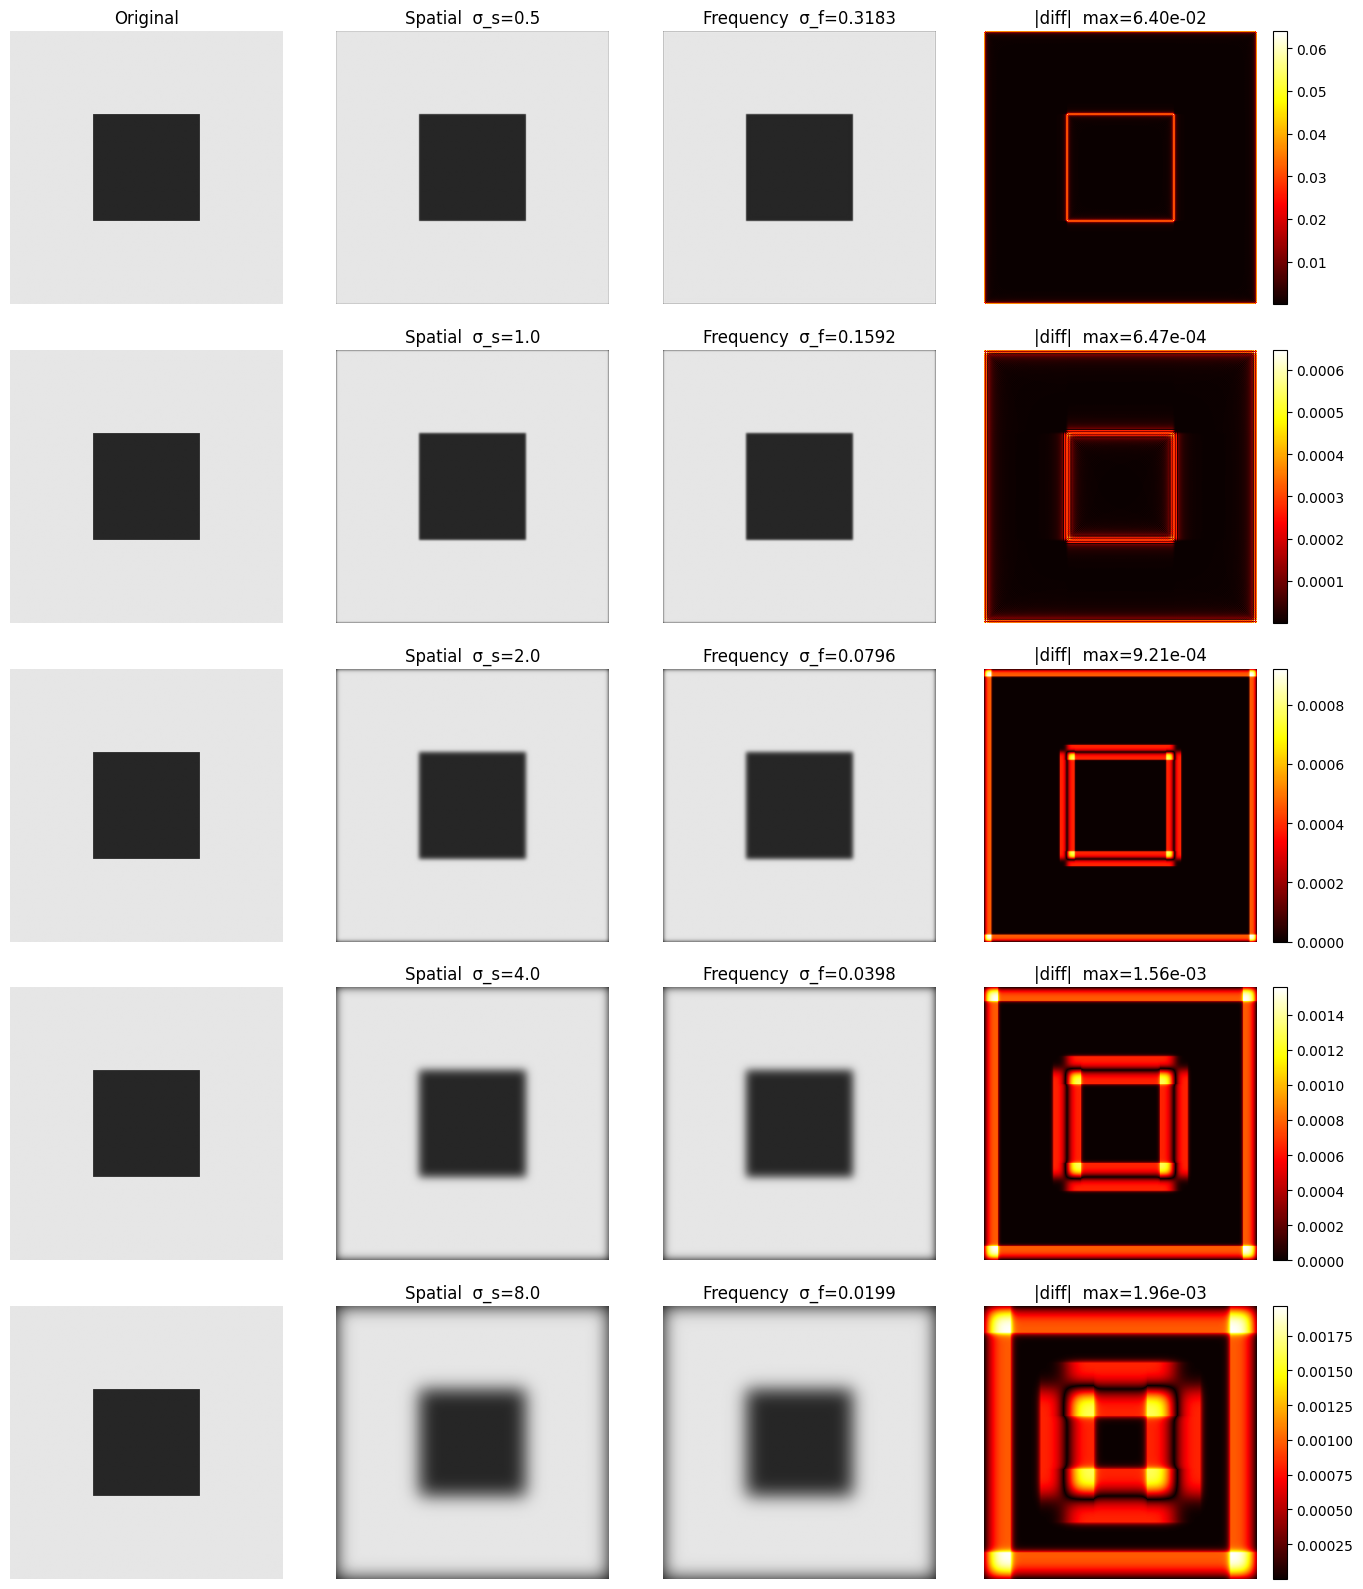

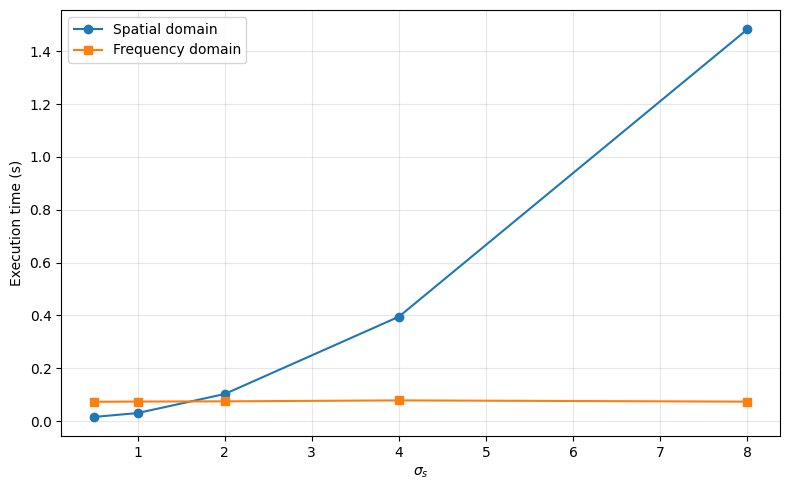

In [60]:
if __name__ == '__main__':
    main()

###  <span style="color:orange"> _Report_ </span>
<span style="color:orange"> _Report your results below. As a test image for this exercise, create an image similar to the one shown in Figure 1. For filtering both spatial and frequency domains assume padding with zero values. In the report, please show examples of filtered images with different pairs of $\sigma_s$ and $\sigma_f$. In particular, include in your report
a plot of the execution time for both domains as a function of $\sigma_s$. Please inline the resulting images with your text explaining the approach (e.g. as figures) so that the report is cohesive._ </span>

So the output showed that the diff is close to 0. Although the diff differs in some locations, this is usually due to differences in boundary treatment, as the spatial domain is zero-padded. So between $\sigma_s$ and the standard deviation $\sigma_f$ in the frequency domain satisfy an inverse proportional relationship: $$\sigma_f = \frac{1}{2\pi\sigma_s}$$  

I set the kernel radius to $3\sigma_s$. For an image of size N, in the Spatial Domain, the complexity is $O(N^2 \cdot \sigma_s^2)$. As $\sigma_s$ increases, the time complexity increases quadratically. 

While in the Frequency Domain, The complexity is $O(N^2 \log N^2)$, which mainly depends on FFT, regardless of the degree of ambiguity $\sigma_s$, the time consumption of frequency domain filtering remains essentially constant.which is more efficient when $\sigma_s$ is extremely large.

So, when $\sigma_s$ is small and $\sigma_f$ is large, the spatial domain only weights the current pixel and its nearest neighbors, with the weights concentrated in the center. In the frequency domain, the Gaussian low-pass filter has a very wide bandwidth. Almost all frequency components can pass through smoothly, resulting in almost no image change and maintaining sharpness, but also meaning no noise reduction effect.  

When $\sigma_s$ is big and $\sigma_f$ is small, the Gaussian kernel in the spatial domain covers a large area of ​​the image. In the frequency domain, the filter is extremely narrow, allowing only components near the origin to pass through. Image effect: The image exhibits severe visual blurring. All edges and details completely disappear.

## 2. Image Restoration [10 points]
Consider a task of removing a repetitive pattern from an image using filtering in the frequency domain. Figure 2 demonstrates an input and the corresponding output of such a procedure. 
### _Tasks_
Design and implement a filtering procedure which perform such restoration. Explain your technique, show Fourier plots of all the steps, as well as the final image. Use the input image provided with the assignment.


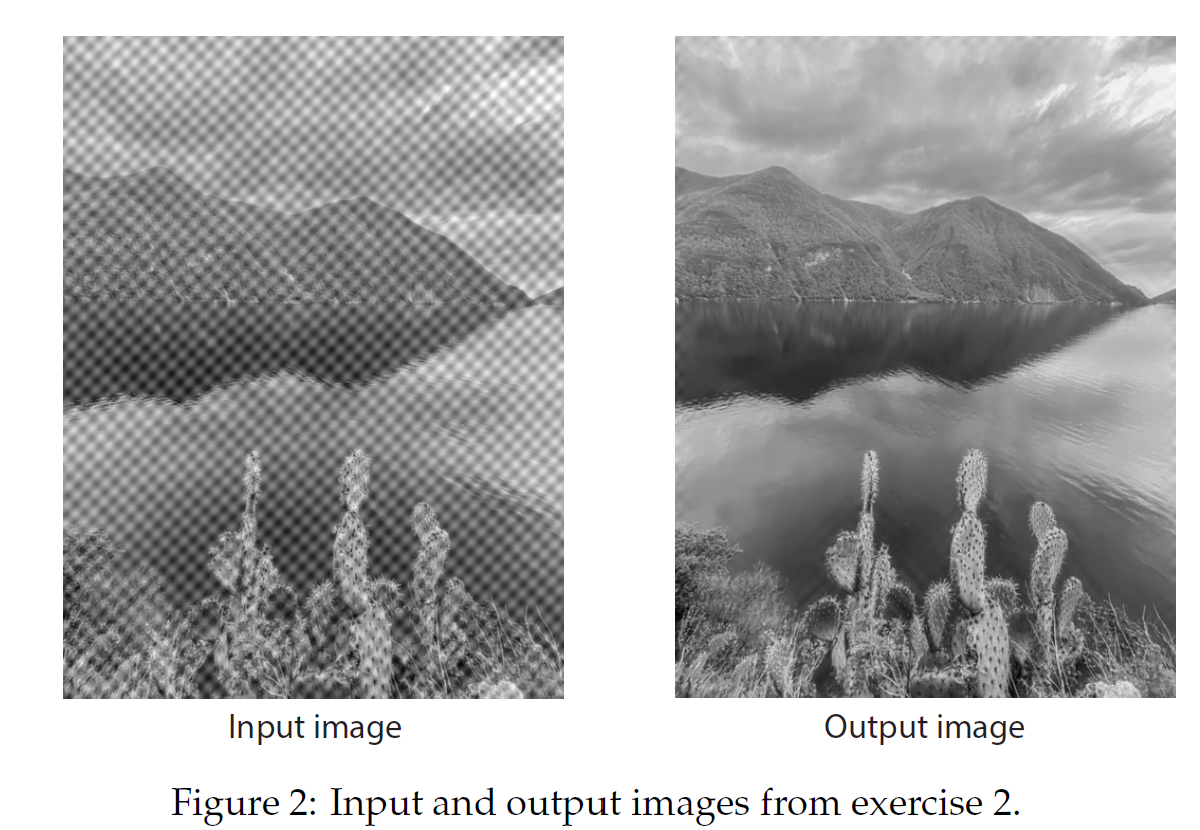

In [61]:
def load_gray(path):
    img = Image.open(path).convert("L")
    return np.asarray(img, dtype=np.float32) / 255.0


def save_gray(path, img):
    img = np.clip(img, 0.0, 1.0)
    Image.fromarray((img * 255).astype(np.uint8)).save(path)


def fft2c(img):
    return np.fft.fftshift(np.fft.fft2(img))


def ifft2c(F):
    return np.real(np.fft.ifft2(np.fft.ifftshift(F)))


def log_magnitude(F):
    return np.log1p(np.abs(F))

# Maximum value filtering.
def maximum_filter_np(arr, size):
    r = size // 2
    H, W = arr.shape
    padded = np.pad(arr, r, mode="edge")
    out = np.zeros_like(arr)
    for dy in range(size):
        for dx in range(size):
            np.maximum(out, padded[dy:dy + H, dx:dx + W], out=out)
    return out


def find_noise_peaks(F, radius=20, min_distance=10, threshold_sigma=6.0):
    mag = log_magnitude(F)
    H, W = mag.shape
    cy, cx = H // 2, W // 2

# Shield the central low-frequency region.
    yy, xx = np.ogrid[:H, :W]
    center = (yy - cy) ** 2 + (xx - cx) ** 2 <= radius ** 2
    work = mag.copy()
    work[center] = 0.0

    local_max = (work == maximum_filter_np(work, size=min_distance))
    valid = work[~center]
    thresh = valid.mean() + threshold_sigma * valid.std()

# Points that simultaneously satisfy both local maxima and the threshold.
    peaks = np.argwhere(local_max & (work > thresh))
    peaks = sorted(peaks.tolist(), key=lambda p: -mag[p[0], p[1]])
    return peaks

# A Gaussian notch filter at each peak position.
def notch_reject_filter(shape, peaks, sigma=8.0):
    yy, xx = np.indices(shape, dtype=np.float32)
    H_filt = np.ones(shape, dtype=np.float32)
    for (py, px) in peaks:
        d2 = (yy - py) ** 2 + (xx - px) ** 2
        H_filt *= 1.0 - np.exp(-d2 / (2.0 * sigma ** 2))
    return H_filt


def restore(img,
            radius=20,
            min_distance=10,
            threshold_sigma=6.0,
            notch_sigma=8.0):
    F        = fft2c(img)
    peaks    = find_noise_peaks(F, radius, min_distance, threshold_sigma)
    H_filt   = notch_reject_filter(F.shape, peaks, sigma=notch_sigma)
    F_clean  = F * H_filt
    restored = ifft2c(F_clean)
    restored = (restored - restored.min()) / (restored.max() - restored.min() + 1e-9)
    return restored, F, F_clean, H_filt, peaks



def plot_pipeline(img, F, H_filt, F_clean, restored, peaks, save_path=None):
    fig, ax = plt.subplots(1, 5, figsize=(20, 5))

    ax[0].imshow(img, cmap="gray")
    ax[0].set_title("Input image"); ax[0].axis("off")

    mag = log_magnitude(F)
    ax[1].imshow(mag, cmap="gray")
    if peaks:
        ys, xs = zip(*peaks)
        ax[1].scatter(xs, ys, s=40, facecolors="none",
                      edgecolors="red", linewidths=1.2,
                      label=f"{len(peaks)} peaks")
        ax[1].legend(loc="upper right", fontsize=8)
    ax[1].set_title("Spectrum")
    ax[1].axis("off")

    ax[2].imshow(H_filt, cmap="gray")
    ax[2].set_title("3. Notch-reject filter"); ax[2].axis("off")

    ax[3].imshow(log_magnitude(F_clean), cmap="gray")
    ax[3].set_title("4. Filtered spectrum"); ax[3].axis("off")

    ax[4].imshow(restored, cmap="gray")
    ax[4].set_title("5. Restored image"); ax[4].axis("off")

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=130, bbox_inches="tight")
    plt.show()



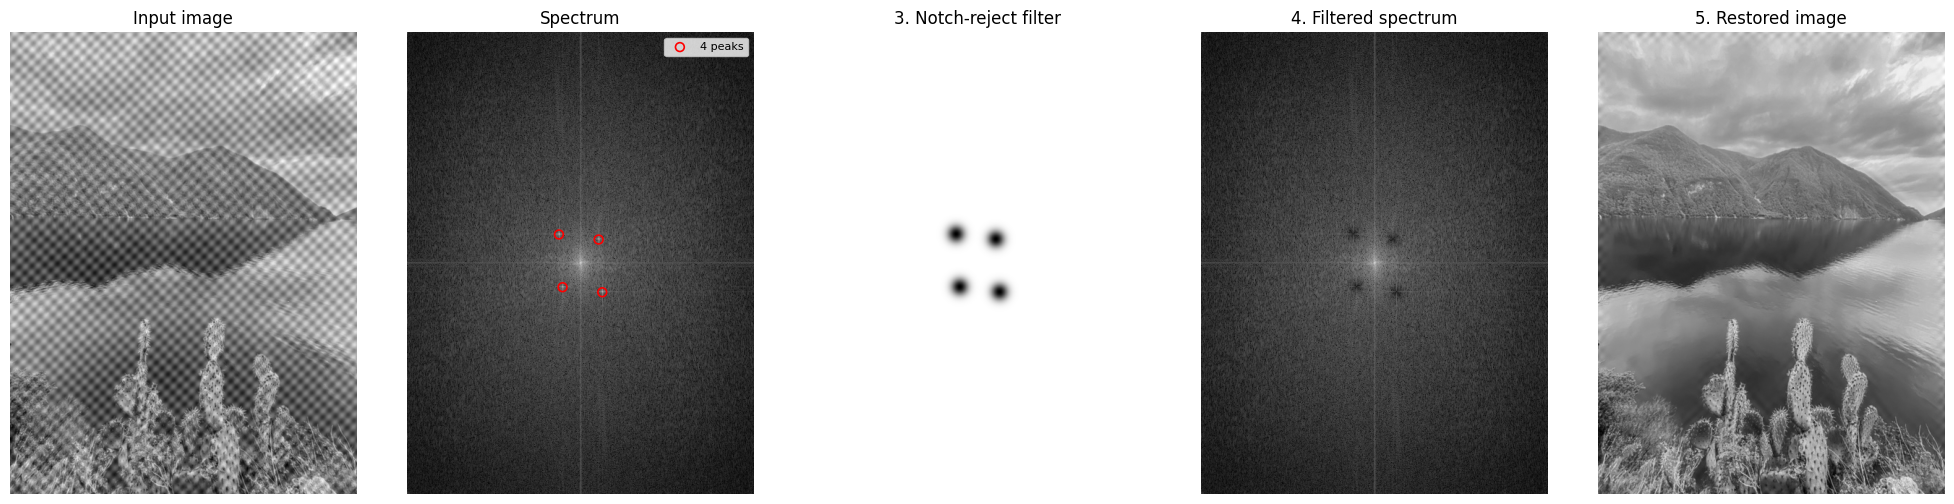

In [62]:
img = load_gray("san_domenico.png")
restored, F, F_clean, H_filt, peaks = restore(img,
                                              radius=20,
                                              min_distance=10,
                                              threshold_sigma=6.0,
                                              notch_sigma=8.0,)
plot_pipeline(img, F, H_filt, F_clean, restored, peaks)

###  <span style="color:orange"> _Report_ </span>
<span style="color:orange"> _Report your results below. Explain your technique, show Fourier plots of all the steps, as well as the final image. Use the input image provided with the assignment. Please inline the resulting images with your text explaining the approach (e.g. as figures) so that the report is cohesive._ </span>

The output displays five images: Input, Spectrum, Filter, Filtered Spectrum, and Output.

In this case, I use Notch Filtering. 

First is the FFT, it transforms the image to the frequency domain. Regular repeating patterns appear as discrete bright spots in the spectrum. The spectral center represents the overall brightness and large-scale structure of the image. It is always the brightest. Therefore, we need to mask it out. Center is a circular mask with the spectral center as its center and a radius. Then it use the maximum filter in the neighbour with threshold to find the pixel which is bright enough.

The Notch Filter places a Gaussian notch at each noise peak location while preserving the central component and its surrounding low-frequency information. Finally it runs IFFT: Inversely transforms the filtered image back to the spatial domain to obtain a clean image.